# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-20: HR PhysFormer v2 - SNR loss

### What this notebook does
Retrains PhysFormer (Temporal-Difference Transformer, Yu et al., CVPR 2022) with the 2026 SNR frequency loss and compares it, on one fixed subject-wise split, against the PhysFormer v1 screen (NB_P3_09, neg-Pearson + frequency-match loss, best val HR MAE 9.71 bpm, MCD 15.93). Everything except the loss is held identical to NB_P3_09 - same architecture, optimizer (Adam, lr 1e-4, weight decay 5e-5), 20-epoch cosine schedule, augmentation and multi-clip sampling - so the change in error isolates the SNR-loss effect on the largest, most data-hungry architecture in the screen.

### Why this experiment
On PhysNet the same swap was the phase's HR breakthrough (NB_P3_18): the SNR loss dropped the shared MCD+DLCN+UBFC MAE from 7.31 to 5.22 and cracked the MCD ceiling (10.69 to 6.84) that every v1 architecture hit and that the Optuna search could not move. PhysFormer lost the v1 screen at 9.71 despite being the largest model (7.38 M), which is the pattern of a transformer starved of a training signal it can exploit. The SNR loss concentrates predicted power at the reference fundamental and first harmonic and ignores the rest of the band, which tolerates a noisy reference such as MCD's pulse-ox - the question here is whether that signal lets the transformer close the gap.

### Recipe and rules
- Loss = neg_pearson + LAMBDA_SNR * snr_loss (in-band SNR at the reference fundamental + first harmonic, per-sample fps, invalid-HR clips masked), each clip weighted by cardiac_sqi.
- One fixed subject-wise split (seed 42) across all four datasets.
- Training corpus = MCD + DLCN + UBFC-rPPG. PhysDrive is evaluation-only (zero-shot), consistent with NB_P3_18 where adding the in-vehicle corpus to training diverged the model.
- Checkpoint on the shared MCD+DLCN+UBFC MAE so PhysDrive's large zero-shot variance never drives selection.
- PhysFormer is used from the official repo (ZitongYu/PhysFormer); our 72x72 clips are upsampled to 128 inside pf_forward. No frames are rendered.

## 1. Imports & Config

In [1]:
import os, sys, time, random, gc, glob, importlib
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

# Clone the official PhysFormer (once) and expose it on the path.
# Pinned to a specific commit so this notebook stays reproducible. The SHA was
# captured 2026-08-29 and may differ from the commit used in the original run,
# which was not recorded. The resolved SHA is printed into this cell's output.
REPO_URL = 'https://github.com/ZitongYu/PhysFormer'
REPO_SHA = '094c6942e8e7ebedf41dd407415d16bc9db34e1d'
if not os.path.exists('PhysFormer'):
    os.system('git init -q PhysFormer && git -C PhysFormer remote add origin ' + REPO_URL)
    os.system('git -C PhysFormer fetch -q --depth 1 origin ' + REPO_SHA)
    os.system('git -C PhysFormer checkout -q FETCH_HEAD')
print('PhysFormer commit:', os.popen('git -C PhysFormer rev-parse HEAD').read().strip())
sys.path.append('PhysFormer')
for d in glob.glob('PhysFormer/**/', recursive=True):
    sys.path.append(d)
os.system('pip install einops -q')

# locate the four Phase-3 datasets across Kaggle inputs (PhysDrive is held-out eval)
WANT = ['mcd_phase3.h5', 'dlcn_phase3.h5', 'ubfc_rppg_phase3.h5', 'physdrive_phase3.h5']
H5_PATHS = []
for name in WANT:
    hits = list(Path('/kaggle/input').rglob(name))
    if hits:
        H5_PATHS.append(hits[0])
print('datasets found:', [p.name for p in H5_PATHS])

TRAIN_SET = {'MCD', 'DLCN', 'UBFC-rPPG'} # PhysDrive excluded from training (held-out)
SHARED_DATASETS = {'MCD', 'DLCN', 'UBFC-rPPG'} # checkpoint metric
V1_SCREEN = {'MCD': 15.93, 'DLCN': 2.14, 'UBFC-rPPG': 2.80} # PhysFormer v1 (NB_P3_09); shared ALL 9.71
V1_SHARED = 9.71

CLIP_LEN = 160
IMG_SIZE = 72
BATCH_SIZE = 4 # transformer is heavier than PhysNet; drop to 2 if OOM
CLIPS_PER_REC = 2
NUM_WORKERS = 2
VAL_FRAC = 0.2
SEED = 42
AUG_PROB = 0.5
SPEED_MIN, SPEED_MAX = 0.7, 2.0
SQI_FLOOR = 0.05

# PhysFormer paper hyperparameters (identical to NB_P3_09; only the loss changes in v2)
LR = 1e-4
WEIGHT_DECAY = 5e-5
EPOCHS = 20
LAMBDA_SNR = 0.05
HR_LOW, HR_HIGH = 0.66, 3.0
PF_DIM, PF_FF, PF_HEADS, PF_LAYERS = 96, 144, 4, 12
PF_THETA, PF_GRA_SHARP, PF_DROPOUT = 0.7, 2.0, 0.1
PF_PATCHES = (4, 4, 4)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True
print('device:', device, '| train on:', sorted(TRAIN_SET), '| PhysDrive = held-out eval')

Cloning into 'PhysFormer'...


datasets found: ['mcd_phase3.h5', 'dlcn_phase3.h5', 'ubfc_rppg_phase3.h5', 'physdrive_phase3.h5']
device: cuda | train on: ['DLCN', 'MCD', 'UBFC-rPPG'] | PhysDrive = held-out eval


## 2. Data Loader - index, one fixed subject-split

In [2]:
def build_index(h5_paths, sqi_floor=SQI_FLOOR, clip_len=CLIP_LEN):
    index = []
    for path in h5_paths:
        with h5py.File(path, 'r') as f:
            for name in f.keys():
                a = f[name].attrs
                if not bool(a.get('usable', True)):
                    continue
                if float(a.get('cardiac_sqi', 0.0)) < sqi_floor:
                    continue
                n = int(a['n_frames'])
                if n < clip_len:
                    continue
                index.append(dict(file=str(path), group=name, dataset=str(a.get('dataset', Path(path).stem)),
                                  subject=str(a.get('subject_id', name)), n_frames=n,
                                  fps=float(a.get('fps', 30.0)), sqi=float(a.get('cardiac_sqi', 0.0))))
    return index


def subject_split(index, val_frac=VAL_FRAC, seed=SEED):
    subjects = sorted({r['dataset'] + '/' + r['subject'] for r in index})
    rng = random.Random(seed); rng.shuffle(subjects)
    n_val = max(1, int(round(len(subjects) * val_frac)))
    val_subj = set(subjects[:n_val])
    tr = [r for r in index if (r['dataset'] + '/' + r['subject']) not in val_subj]
    va = [r for r in index if (r['dataset'] + '/' + r['subject']) in val_subj]
    return tr, va, val_subj


def compute_hr(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(x.size))) ** 2
    fr = np.fft.rfftfreq(x.size, 1.0 / fps)
    b = (fr >= low) & (fr <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(fr[b][int(np.argmax(p[b]))] * 60.0)


class RPPGClipDataset(Dataset):
    def __init__(self, index, clip_len=CLIP_LEN, augment=False, clips_per_rec=1,
                 aug_prob=AUG_PROB, speed_range=(SPEED_MIN, SPEED_MAX), seed=SEED):
        self.index = index; self.clip_len = clip_len; self.augment = augment
        self.clips_per_rec = clips_per_rec; self.aug_prob = aug_prob; self.speed_range = speed_range
        self._files = {}; self._rng = np.random.default_rng(seed)

    def _h5(self, path):
        h = self._files.get(path)
        if h is None:
            h = h5py.File(path, 'r'); self._files[path] = h
        return h

    def __len__(self):
        return len(self.index) * self.clips_per_rec

    def __getitem__(self, i):
        rec = self.index[i % len(self.index)]; g = self._h5(rec['file'])[rec['group']]
        n, T = rec['n_frames'], self.clip_len
        if self.augment and self._rng.random() < self.aug_prob:
            src_len = int(round(T * float(self._rng.uniform(*self.speed_range))))
            src_len = max(T, min(src_len, n))
        else:
            src_len = T
        max_start = n - src_len
        start = int(self._rng.integers(0, max_start + 1)) if (self.augment and max_start > 0) else max_start // 2
        frames_src = g['frames'][start:start + src_len].astype(np.float32)
        bvp_src = g['bvp'][start:start + src_len].astype(np.float32)
        pos = np.linspace(0, src_len - 1, T)
        frames = frames_src[np.rint(pos).astype(int)]
        bvp = np.interp(pos, np.arange(src_len), bvp_src)
        hr_bpm = compute_hr(bvp, rec['fps'])
        if self.augment and self._rng.random() < 0.5:
            frames = frames[:, :, ::-1, :]
        m = frames.mean(axis=(0, 1, 2), keepdims=True); sd = frames.std(axis=(0, 1, 2), keepdims=True) + 1e-6
        frames = np.ascontiguousarray((frames - m) / sd)
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2).float()
        bvp = (bvp - bvp.mean()) / (bvp.std() + 1e-6)
        bvp = torch.from_numpy(bvp.astype(np.float32))
        return dict(frames=frames, bvp=bvp,
                    hr=torch.tensor(hr_bpm if np.isfinite(hr_bpm) else 0.0, dtype=torch.float32),
                    sqi=torch.tensor(rec['sqi'], dtype=torch.float32),
                    fps=torch.tensor(rec['fps'], dtype=torch.float32),
                    dataset=rec['dataset'])


def worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info(); ds = info.dataset
    ds._files = {}; ds._rng = np.random.default_rng(SEED + 1000 * (worker_id + 1) + int(info.seed % 100000))


def make_loader(index, augment, clips_per_rec=1):
    ds = RPPGClipDataset(index, augment=augment, clips_per_rec=clips_per_rec)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=augment, num_workers=NUM_WORKERS,
                      worker_init_fn=worker_init_fn, pin_memory=True, drop_last=augment,
                      persistent_workers=(NUM_WORKERS > 0))


index = build_index(H5_PATHS)
train_all, val_idx, val_subj = subject_split(index)   # ONE fixed split
train_idx = [r for r in train_all if r['dataset'] in TRAIN_SET]
print('usable:', len(index), 'by dataset:', dict(Counter(r['dataset'] for r in index)))
print('val (FIXED):', len(val_idx), 'by dataset:', dict(Counter(r['dataset'] for r in val_idx)))
print('train recs:', len(train_idx), 'by dataset:', dict(Counter(r['dataset'] for r in train_idx)))

usable: 2276 by dataset: {'MCD': 1191, 'DLCN': 777, 'UBFC-rPPG': 42, 'PhysDrive': 266}
val (FIXED): 475 by dataset: {'MCD': 232, 'DLCN': 168, 'UBFC-rPPG': 7, 'PhysDrive': 68}
train recs: 1603 by dataset: {'MCD': 959, 'DLCN': 609, 'UBFC-rPPG': 35}


## 3. Model - PhysFormer (official repo)

In [3]:
PhysFormerClass = None
for modname in ['model.Physformer', 'model.physformer', 'Physformer']:
    try:
        m = importlib.import_module(modname)
        PhysFormerClass = getattr(m, 'ViT_ST_ST_Compact3_TDC_gra_sharp')
        print('imported PhysFormer from', modname)
        break
    except Exception as e:
        print('import', modname, 'failed:', repr(e))
if PhysFormerClass is None:
    raise RuntimeError('could not import ViT_ST_ST_Compact3_TDC_gra_sharp')

PF_INPUT = 128   # PhysFormer official spatial size; our 72x72 clips are upsampled to this

def build_physformer():
    return PhysFormerClass(image_size=(CLIP_LEN, PF_INPUT, PF_INPUT), patches=PF_PATCHES,
                           dim=PF_DIM, ff_dim=PF_FF, num_heads=PF_HEADS, num_layers=PF_LAYERS,
                           dropout_rate=PF_DROPOUT, theta=PF_THETA)

def _spatial_resize(x, size=PF_INPUT):
    B, C, T, H, W = x.shape
    if H == size and W == size:
        return x
    x = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)
    x = torch.nn.functional.interpolate(x, size=(size, size), mode='bilinear', align_corners=False)
    return x.reshape(B, T, C, size, size).permute(0, 2, 1, 3, 4).contiguous()

def pf_forward(model, x):
    x = _spatial_resize(x, PF_INPUT)
    try:
        out = model(x, PF_GRA_SHARP)          # PhysFormer returns (rPPG, Score1, Score2, Score3)
    except TypeError:
        out = model(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    if out.dim() == 3 and out.shape[-1] == 1:
        out = out.squeeze(-1)
    return out

imported PhysFormer from model.Physformer


## 4. Losses & Evaluation

In [4]:
def neg_pearson(pred, target):
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    num = (pred * target).sum(dim=1)
    den = torch.sqrt((pred ** 2).sum(dim=1) * (target ** 2).sum(dim=1) + 1e-8)
    return 1.0 - num / (den + 1e-8)


def snr_loss(pred, hr_bpm, fps, low=HR_LOW, high=HR_HIGH, delta_bpm=8.0):
    '''Negative in-band SNR (dB): power at the true fundamental (+first harmonic) vs the rest of the HR band. fp32.'''
    pred = pred.float(); pred = pred - pred.mean(dim=1, keepdim=True)
    B, T = pred.shape
    P = torch.abs(torch.fft.rfft(pred, dim=1)) ** 2
    Fn = P.shape[1]
    k = torch.arange(Fn, device=pred.device).float()
    freqs = k[None, :] * fps[:, None] / float(T)
    f0 = (hr_bpm / 60.0).clamp(min=low + 0.05, max=high - 0.05)[:, None]
    d = delta_bpm / 60.0
    band = (freqs >= low) & (freqs <= high)
    sig = (((freqs - f0).abs() <= d) | ((freqs - 2.0 * f0).abs() <= d)) & band
    noise = band & (~sig)
    sig_p = (P * sig).sum(dim=1) + 1e-8
    noise_p = (P * noise).sum(dim=1) + 1e-8
    return (-10.0 * torch.log10(sig_p / noise_p)).clamp(-30.0, 30.0)


def hr_from_bvp(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.std() < 1e-8:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(f[b][int(np.argmax(p[b]))] * 60.0)


@torch.no_grad()
def evaluate(model, loader):
    '''Returns dict with overall MAE, shared (MCD+DLCN+UBFC) MAE, per-dataset MAE, and r.'''
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = pf_forward(model, frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    df = pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])
    if len(df) == 0:
        return dict(all=1e9, shared=1e9, per={}, r=float('nan'), n=0)
    df['ae'] = (df.hr_pred - df.hr_true).abs()
    per = df.groupby('dataset')['ae'].mean().round(3).to_dict()
    shared = df[df.dataset.isin(SHARED_DATASETS)]['ae']
    return dict(all=float(df.ae.mean()),
                shared=float(shared.mean()) if len(shared) else float(df.ae.mean()),
                per=per, n=int(len(df)),
                r=float(np.corrcoef(df.hr_true, df.hr_pred)[0, 1]) if len(df) > 2 else float('nan'))

## 5. Sanity check
Verifies the PhysFormer clone imports, the model builds at ~7.38 M parameters, a batch flows through pf_forward to a [B, CLIP_LEN] waveform, and the two loss terms return finite values. Frame tensors are checked numerically only; no frames are rendered.

In [5]:
_tl = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
_vl = make_loader(val_idx, augment=False, clips_per_rec=1)
print('train clips/epoch:', len(_tl.dataset), '| val clips:', len(_vl.dataset))

model = build_physformer().to(device)
print('PhysFormer params:', round(sum(p.numel() for p in model.parameters()) / 1e6, 2), 'M')

batch = next(iter(_tl))
print('batch frames', tuple(batch['frames'].shape), '| bvp', tuple(batch['bvp'].shape))
print('frames dtype', batch['frames'].dtype, '| mean', round(float(batch['frames'].mean()), 3), '| std', round(float(batch['frames'].std()), 3))
with torch.no_grad():
    out = pf_forward(model, batch['frames'][:2].to(device))
print('model output', tuple(out.shape), '(expect [2,', CLIP_LEN, '])')
hr2 = batch['hr'][:2].to(device); fps2 = batch['fps'][:2].to(device); bvp2 = batch['bvp'][:2].to(device)
print('neg_pearson sample:', round(float(neg_pearson(out.float(), bvp2).mean()), 4))
print('snr_loss sample:', [round(float(v), 3) for v in snr_loss(out.float(), hr2, fps2)])
del model, _tl, _vl, batch, out; gc.collect(); torch.cuda.empty_cache()

train clips/epoch: 3206 | val clips: 475
PhysFormer params: 7.38 M
batch frames (4, 3, 160, 72, 72) | bvp (4, 160)
frames dtype torch.float32 | mean -0.0 | std 1.0
model output (2, 160) (expect [2, 160 ])
neg_pearson sample: 1.0437
snr_loss sample: [6.525, 14.214]


## 6. Training
Trains PhysFormer on MCD + DLCN + UBFC-rPPG with the SNR-loss recipe, evaluates all four datasets each epoch (PhysDrive zero-shot), and checkpoints on the shared MCD+DLCN+UBFC MAE.

In [6]:
train_loader = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)
print('train recs', len(train_idx), 'by ds', dict(Counter(r['dataset'] for r in train_idx)), '| clips/epoch', len(train_loader.dataset))

torch.manual_seed(SEED)
model = build_physformer().to(device)
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
scaler = GradScaler('cuda')
ckpt = 'physformer_v2_best.pt'
best = 1e9; best_per = {}; best_all = None; best_epoch = -1; hist = []
for epoch in range(EPOCHS):
    model.train(); t0 = time.time()
    for batch in train_loader:
        frames = batch['frames'].to(device, non_blocking=True)
        bvp = batch['bvp'].to(device, non_blocking=True)
        sqi = batch['sqi'].to(device, non_blocking=True)
        hr = batch['hr'].to(device, non_blocking=True)
        fps = batch['fps'].to(device, non_blocking=True)
        valid = ((hr >= 40) & (hr <= 180)).float()
        opt.zero_grad(set_to_none=True)
        with autocast('cuda'):
            pred = pf_forward(model, frames)
        pred = pred.float()
        per_loss = neg_pearson(pred, bvp) + LAMBDA_SNR * (snr_loss(pred, hr, fps) * valid)
        w = sqi.clamp(min=1e-3)
        loss = (per_loss * w).sum() / w.sum()
        scaler.scale(loss).backward(); scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt); scaler.update()
    sched.step()
    res = evaluate(model, val_loader)
    hist.append(dict(epoch=epoch + 1, shared=res['shared'], all=res['all'], r=res['r'],
                     **{('mae_' + k): v for k, v in res['per'].items()}))
    print('ep', epoch + 1, '/', EPOCHS, '|', round(time.time() - t0), 's | shared', round(res['shared'], 2), '| all', round(res['all'], 2), '|', res['per'])
    if res['shared'] < best:
        best = res['shared']; best_per = res['per']; best_all = res['all']; best_epoch = epoch + 1
        torch.save(model.state_dict(), ckpt); print('   * new best shared', round(best, 2))
torch.save(model.state_dict(), 'physformer_v2_last.pt')
hist_df = pd.DataFrame(hist); hist_df.to_csv('history_physformer_v2.csv', index=False)
print('DONE | best shared MAE', round(best, 2), '@ep', best_epoch, '| per-dataset', best_per)
print('PhysFormer v1 (NB_P3_09) shared MAE was', V1_SHARED)

train recs 1603 by ds {'MCD': 959, 'DLCN': 609, 'UBFC-rPPG': 35} | clips/epoch 3206
ep 1 / 20 | 495 s | shared 23.81 | all 23.46 | {'DLCN': 18.817, 'MCD': 27.648, 'PhysDrive': 21.342, 'UBFC-rPPG': 16.681}
   * new best shared 23.81
ep 2 / 20 | 455 s | shared 15.57 | all 17.35 | {'DLCN': 11.25, 'MCD': 18.937, 'PhysDrive': 27.96, 'UBFC-rPPG': 7.873}
   * new best shared 15.57
ep 3 / 20 | 444 s | shared 12.2 | all 14.12 | {'DLCN': 6.696, 'MCD': 16.456, 'PhysDrive': 25.643, 'UBFC-rPPG': 3.118}
   * new best shared 12.2
ep 4 / 20 | 438 s | shared 8.46 | all 10.16 | {'DLCN': 5.759, 'MCD': 10.583, 'PhysDrive': 20.349, 'UBFC-rPPG': 3.118}
   * new best shared 8.46
ep 5 / 20 | 440 s | shared 9.8 | all 11.76 | {'DLCN': 5.022, 'MCD': 13.469, 'PhysDrive': 23.493, 'UBFC-rPPG': 3.118}
ep 6 / 20 | 443 s | shared 9.3 | all 11.04 | {'DLCN': 5.424, 'MCD': 12.051, 'PhysDrive': 21.507, 'UBFC-rPPG': 10.868}
ep 7 / 20 | 437 s | shared 7.62 | all 10.18 | {'DLCN': 4.353, 'MCD': 10.077, 'PhysDrive': 25.478, 'U

## 7. Comparison - PhysFormer v1 (NB_P3_09) vs v2 SNR loss

In [7]:
order = ['MCD', 'DLCN', 'UBFC-rPPG', 'PhysDrive']
tab = []
for dname in order:
    tab.append(dict(dataset=dname, v1_NB09=V1_SCREEN.get(dname, np.nan), v2_snr=best_per.get(dname, np.nan)))
comp = pd.DataFrame(tab).set_index('dataset')
comp.loc['shared-3 (ckpt metric)'] = [V1_SHARED, best]
comp.loc['ALL (incl PhysDrive)'] = [np.nan, best_all]
comp['delta_v2_minus_v1'] = (comp['v2_snr'] - comp['v1_NB09']).round(2)
print('PhysFormer v1 (neg-Pearson + freq) vs v2 (neg-Pearson + SNR) - HR MAE bpm; PhysDrive is zero-shot in both')
print(comp.round(2).to_string())
print('')
print('Reads:')
print('  v1_NB09 -> v2_snr on shared-3   = the SNR-loss effect on the fixed corpus')
print('  MCD row                         = whether the SNR loss cracks the noisy-reference ceiling as it did on PhysNet')
print('  PhysDrive row                   = the hard in-vehicle held-out benchmark (zero-shot)')

PhysFormer v1 (neg-Pearson + freq) vs v2 (neg-Pearson + SNR) - HR MAE bpm; PhysDrive is zero-shot in both
                        v1_NB09  v2_snr  delta_v2_minus_v1
dataset                                                   
MCD                       15.93    7.70              -8.24
DLCN                       2.14    2.88               0.74
UBFC-rPPG                  2.80    3.12               0.32
PhysDrive                   NaN   30.94                NaN
shared-3 (ckpt metric)     9.71    5.63              -4.08
ALL (incl PhysDrive)        NaN    9.25                NaN

Reads:
  v1_NB09 -> v2_snr on shared-3   = the SNR-loss effect on the fixed corpus
  MCD row                         = whether the SNR loss cracks the noisy-reference ceiling as it did on PhysNet
  PhysDrive row                   = the hard in-vehicle held-out benchmark (zero-shot)


## 8. Post-training evaluation & Bland-Altman

zero-shot datasets: ['PhysDrive']
               n    MAE   RMSE   bias  LoA_low  LoA_high  Pearson_r
DLCN       168.0   2.88  10.59   0.07   -20.76     20.89       0.76
MCD        232.0   7.70  16.32   0.81   -31.21     32.83       0.46
PhysDrive   68.0  30.94  43.76  29.28   -34.93     93.50       0.12
UBFC-rPPG    7.0   3.12   5.83  -0.02   -12.37     12.33       0.97
ALL        475.0   9.25  21.08   4.61   -35.75     44.98       0.34


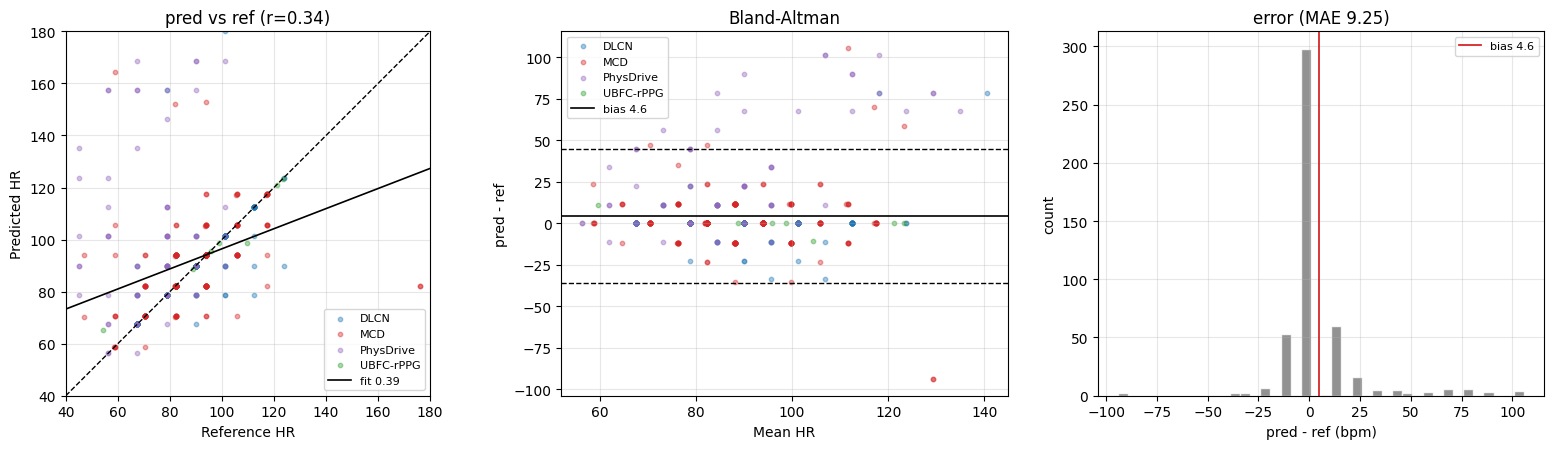

In [8]:
import matplotlib.pyplot as plt

@torch.no_grad()
def collect_predictions(model, loader):
    rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        with autocast('cuda'):
            pred = pf_forward(model, frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])

def metrics_block(g):
    d = (g['hr_pred'] - g['hr_true']).values
    sd = d.std(ddof=1) if len(d) > 1 else np.nan
    return pd.Series(dict(n=len(g), MAE=np.abs(d).mean(), RMSE=np.sqrt((d ** 2).mean()), bias=d.mean(),
                          LoA_low=d.mean() - 1.96 * sd, LoA_high=d.mean() + 1.96 * sd,
                          Pearson_r=(np.corrcoef(g['hr_true'], g['hr_pred'])[0, 1] if len(g) > 2 else np.nan)))

colors = dict(MCD='tab:red', DLCN='tab:blue')
colors['UBFC-rPPG'] = 'tab:green'; colors['PhysDrive'] = 'tab:purple'
val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)

model = build_physformer().to(device)
model.load_state_dict(torch.load(ckpt, map_location=device)); model.eval()
pred_df = collect_predictions(model, val_loader)
summary = pred_df.groupby('dataset').apply(metrics_block, include_groups=False)
overall = metrics_block(pred_df); overall.name = 'ALL'
zs = [d for d in summary.index if d not in TRAIN_SET]
print('zero-shot datasets:', zs)
print(pd.concat([summary, overall.to_frame().T]).round(2).to_string())

diff = (pred_df.hr_pred - pred_df.hr_true).values
bias = diff.mean(); sd = diff.std(ddof=1)
r = np.corrcoef(pred_df.hr_true, pred_df.hr_pred)[0, 1]
lim = [40, 180]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for ds, g in pred_df.groupby('dataset'):
    ax[0].scatter(g.hr_true, g.hr_pred, s=10, alpha=0.4, color=colors.get(ds, 'gray'), label=ds)
ax[0].plot(lim, lim, 'k--', lw=1)
sl, ic = np.polyfit(pred_df.hr_true, pred_df.hr_pred, 1)
ax[0].plot(np.array(lim), ic + sl * np.array(lim), 'k-', lw=1.2, label='fit ' + str(round(sl, 2)))
ax[0].set(xlim=lim, ylim=lim, xlabel='Reference HR', ylabel='Predicted HR', title='pred vs ref (r=' + str(round(r, 2)) + ')', aspect='equal')
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
for ds, g in pred_df.groupby('dataset'):
    ax[1].scatter((g.hr_true + g.hr_pred) / 2, g.hr_pred - g.hr_true, s=10, alpha=0.4, color=colors.get(ds, 'gray'), label=ds)
ax[1].axhline(bias, color='k', lw=1.2, label='bias ' + str(round(bias, 1)))
ax[1].axhline(bias + 1.96 * sd, color='k', ls='--', lw=1); ax[1].axhline(bias - 1.96 * sd, color='k', ls='--', lw=1)
ax[1].set(xlabel='Mean HR', ylabel='pred - ref', title='Bland-Altman'); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[2].hist(diff, bins=40, color='tab:gray', alpha=0.85, edgecolor='white')
ax[2].axvline(bias, color='tab:red', lw=1.3, label='bias ' + str(round(bias, 1)))
ax[2].set(xlabel='pred - ref (bpm)', ylabel='count', title='error (MAE ' + str(round(np.abs(diff).mean(), 2)) + ')')
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
del model; gc.collect(); torch.cuda.empty_cache()

## 9. Discussion and conclusions

Swapping only the training loss - from neg-Pearson + frequency-match to neg-Pearson + SNR, with architecture, optimizer, schedule, augmentation and the fixed subject-wise split held identical to NB_P3_09 - moved PhysFormer's shared MCD+DLCN+UBFC MAE from 9.71 to 5.63 and, within it, MCD from 15.93 to 7.70. DLCN (2.14 to 2.88) and UBFC-rPPG (2.80 to 3.12) shifted slightly the other way, but the shared metric is dominated by the MCD collapse. Training was stable: the shared MAE fell from 23.8 at epoch 1 to its 5.63 best at epoch 18 with only mild epoch-to-epoch noise and no divergence.

This reproduces on the largest, most data-hungry architecture the effect first seen on PhysNet (MCD 10.69 to 6.84): concentrating predicted power at the reference fundamental and first harmonic tolerates MCD's noisy pulse-ox reference, and the largest gain again lands on MCD. The SNR-loss benefit is therefore not PhysNet-specific - it is a property of the loss on the noisy-reference set.

PhysFormer does not, however, displace PhysNet. At 5.63 shared / 7.70 MCD it stays behind the SNR-loss PhysNet (5.22 / 6.84) while carrying roughly ten times the parameters (7.38 M vs 0.77 M), so PhysNet remains the deployable HR backbone and PhysFormer is retained as a well-characterised second reference.

PhysDrive stayed at 30.9 bpm zero-shot with a large positive bias, higher than every clean set and no better than PhysNet's zero-shot number. No architecture or loss change has moved the in-vehicle benchmark, confirming it as a data/domain problem rather than a modelling one.